# Sistema de prediccion de ventas con ARIMA

Este proyecto construye una serie temporal de ventas y entrena un modelo ARIMA para estimar ventas futuras. La meta es anticipar el ritmo de crecimiento de la empresa para planificar el espacio necesario en un nuevo almacen.

El flujo sigue las instrucciones del proyecto:

- Cargar `sales.csv`.
- Construir una serie temporal valida.
- Analizar tensor, tendencia, estacionariedad y ruido.
- Separar train y test.
- Buscar la mejor parametrizacion ARIMA.
- Predecir sobre test y medir rendimiento.
- Guardar el modelo entrenado.

## Paso 1: Carga del conjunto de datos

In [1]:
%matplotlib inline

from itertools import product
from pathlib import Path
import pickle
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 30)

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
DATA_URL = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
RAW_DATA_PATH = ROOT_DIR / "data" / "raw" / "sales.csv"
SERIES_PATH = ROOT_DIR / "data" / "processed" / "sales_time_series.csv"
GRID_RESULTS_PATH = ROOT_DIR / "data" / "processed" / "arima_grid_results.csv"
TEST_FORECAST_PATH = ROOT_DIR / "data" / "processed" / "arima_test_forecast.csv"
FUTURE_FORECAST_PATH = ROOT_DIR / "data" / "processed" / "arima_future_forecast_60_days.csv"
METRICS_PATH = ROOT_DIR / "data" / "processed" / "arima_metrics.csv"
MODEL_PATH = ROOT_DIR / "models" / "sales_arima_model.pkl"

RAW_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
SERIES_PATH.parent.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if RAW_DATA_PATH.exists():
    df = pd.read_csv(RAW_DATA_PATH)
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(RAW_DATA_PATH, index=False)

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())
display(df.tail())

Filas: 366 | Columnas: 2


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


,date,sales
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214
365,2023-09-03 17:10:08.079328,1000.482785


El dataset tiene dos columnas: `date` y `sales`. Para trabajar con ARIMA necesitamos convertir `date` a formato fecha, ordenarla y usarla como indice temporal.

## Paso 2: Construccion y analisis de la serie temporal

In [2]:
series_df = df.copy()
series_df["date"] = pd.to_datetime(series_df["date"]).dt.normalize()
series_df = series_df.sort_values("date").drop_duplicates(subset="date")
series = series_df.set_index("date")["sales"].asfreq("D")
series = series.interpolate(method="time")
series.to_frame("sales").to_csv(SERIES_PATH)

print(f"Fecha inicial: {series.index.min().date()}")
print(f"Fecha final: {series.index.max().date()}")
print(f"Frecuencia inferida: {pd.infer_freq(series.index)}")
print(f"Valores faltantes: {series.isna().sum()}")
print(f"Tensor de la serie temporal: diario")
display(series.describe().round(3).to_frame("sales"))

Fecha inicial: 2022-09-03
Fecha final: 2023-09-03
Frecuencia inferida: D
Valores faltantes: 0
Tensor de la serie temporal: diario


,sales
count,366.000
mean,524.964
std,275.090
min,53.803
25%,290.187
50%,520.699
75%,763.289
max,1000.483


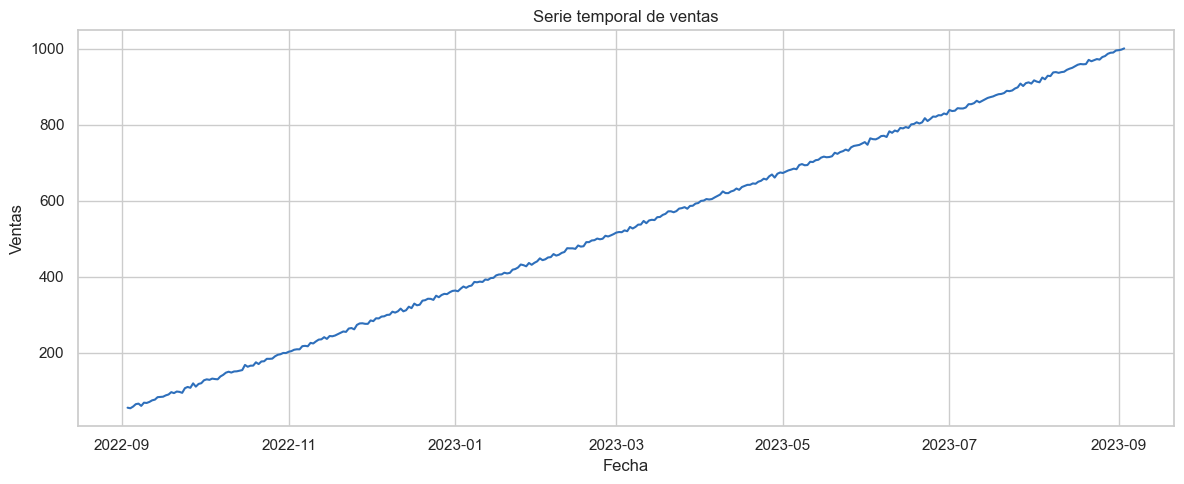

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, color="#2E6FBB")
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

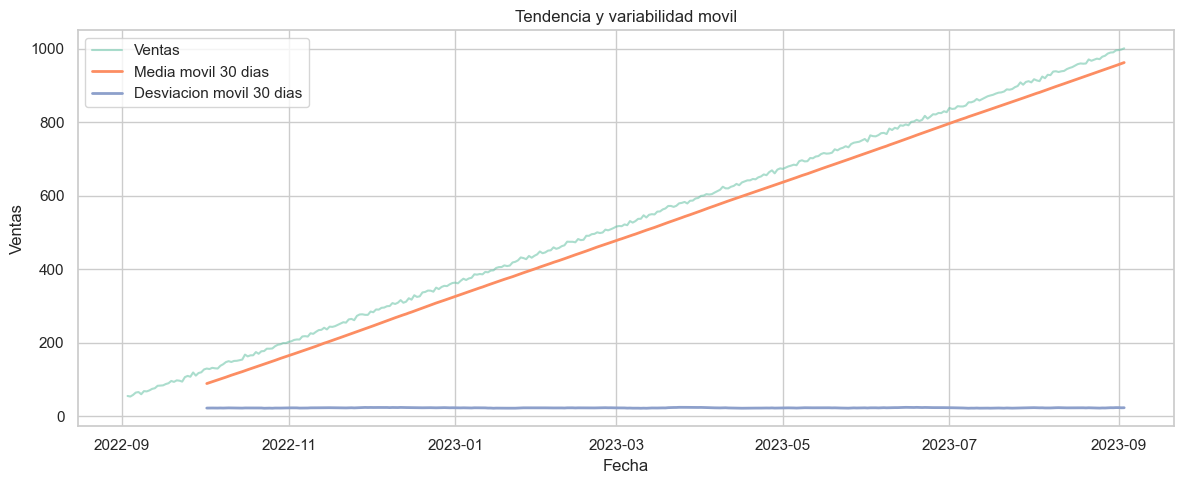

In [4]:
rolling_mean = series.rolling(window=30).mean()
rolling_std = series.rolling(window=30).std()

plt.figure(figsize=(12, 5))
plt.plot(series, label="Ventas", alpha=0.55)
plt.plot(rolling_mean, label="Media movil 30 dias", linewidth=2)
plt.plot(rolling_std, label="Desviacion movil 30 dias", linewidth=2)
plt.title("Tendencia y variabilidad movil")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

**Analisis inicial:**

- **Tensor:** diario, porque hay una observacion por dia.
- **Tendencia:** claramente creciente; las ventas pasan de valores cercanos a 55 hasta aproximadamente 1000.
- **Variabilidad o ruido:** existe fluctuacion alrededor de la tendencia, aunque el patron general es muy estable y ascendente.

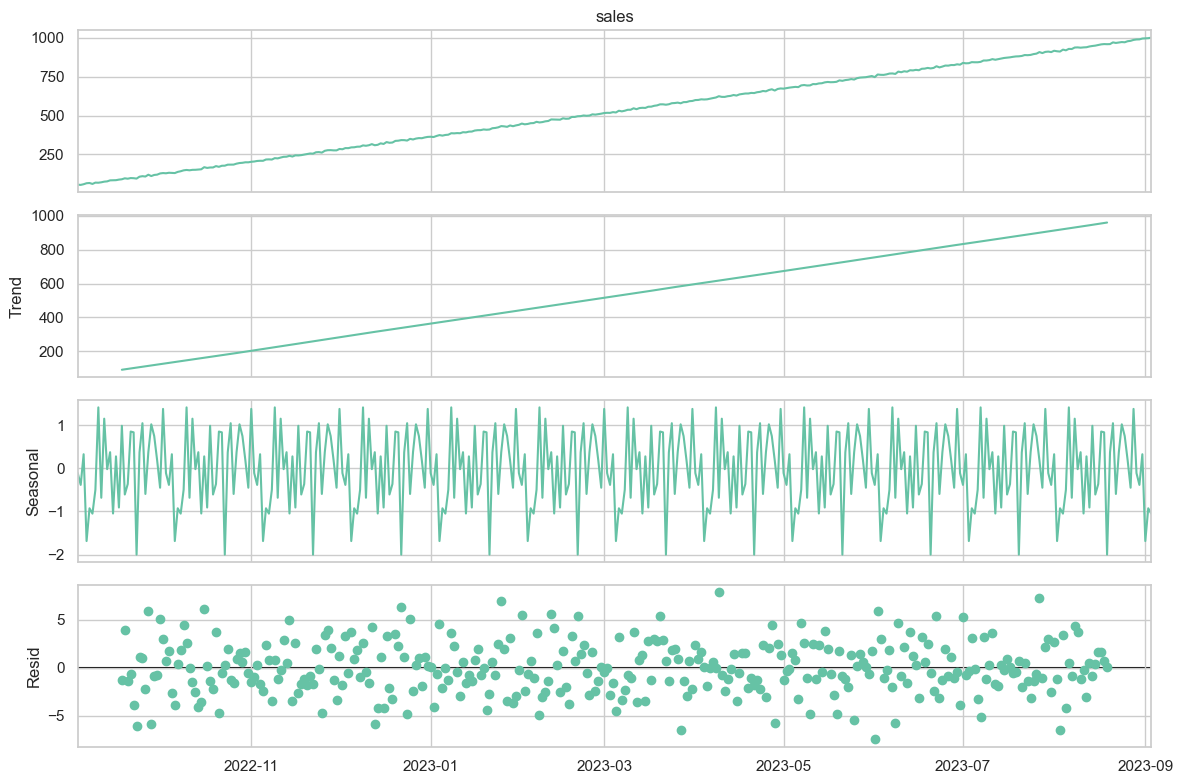

In [5]:
decomposition = seasonal_decompose(series, model="additive", period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [6]:
adf_original = adfuller(series.dropna())
adf_diff1 = adfuller(series.diff().dropna())
adf_diff2 = adfuller(series.diff().diff().dropna())

adf_results = pd.DataFrame([
    {"serie": "original", "adf_statistic": adf_original[0], "p_value": adf_original[1]},
    {"serie": "diff_1", "adf_statistic": adf_diff1[0], "p_value": adf_diff1[1]},
    {"serie": "diff_2", "adf_statistic": adf_diff2[0], "p_value": adf_diff2[1]},
])

display(adf_results.round(6))

,serie,adf_statistic,p_value
0,original,0.545414,0.98619
1,diff_1,-9.430263,0.00000
2,diff_2,-12.254451,0.00000


La prueba ADF sobre la serie original tiene un `p-value` alto, por lo que no se considera estacionaria. Al aplicar una primera diferenciacion, el `p-value` cae por debajo de 0.05, indicando que la serie diferenciada si es estacionaria. Esto justifica usar diferenciacion en ARIMA.

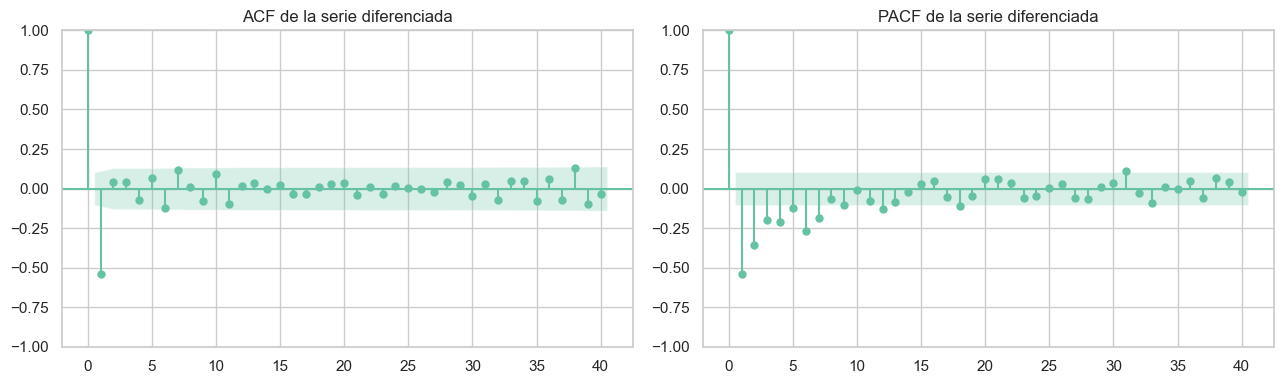

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series.diff().dropna(), lags=40, ax=axes[0])
plot_pacf(series.diff().dropna(), lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF de la serie diferenciada")
axes[1].set_title("PACF de la serie diferenciada")
plt.tight_layout()
plt.show()

## Paso 3: Entrenamiento y parametrizacion de ARIMA

In [8]:
train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test = series.iloc[train_size:]

print(f"Train: {len(train)} dias")
print(f"Test: {len(test)} dias")
print(f"Inicio test: {test.index.min().date()} | Fin test: {test.index.max().date()}")

Train: 292 dias
Test: 74 dias
Inicio test: 2023-06-22 | Fin test: 2023-09-03


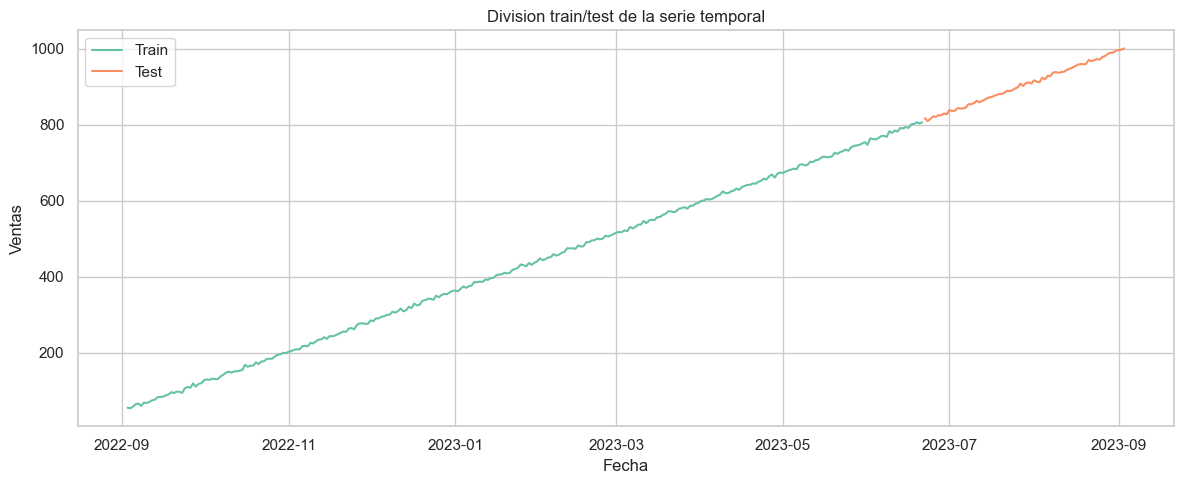

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Division train/test de la serie temporal")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def search_arima_order(train_series):
    results = []
    for p, d, q in product(range(0, 4), range(1, 3), range(0, 6)):
        try:
            model = ARIMA(
                train_series,
                order=(p, d, q),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fitted = model.fit()
            results.append({"p": p, "d": d, "q": q, "aic": fitted.aic, "bic": fitted.bic})
        except Exception:
            continue
    results_df = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
    best_order = tuple(results_df.loc[0, ["p", "d", "q"]].astype(int))
    return best_order, results_df

best_order, grid_results = search_arima_order(train)
grid_results.to_csv(GRID_RESULTS_PATH, index=False)

print(f"Mejor orden ARIMA encontrado: {best_order}")
display(grid_results.head(10).round(3))

Mejor orden ARIMA encontrado: (0, 2, 5)


,p,d,q,aic,bic
0,0,2,5,1448.433,1470.327
1,2,2,4,1453.483,1479.051
2,1,2,5,1453.986,1479.528
3,0,2,4,1455.305,1473.568
4,1,2,4,1455.536,1477.451
5,3,2,5,1456.082,1488.923
6,3,2,4,1457.102,1486.322
7,0,2,3,1457.213,1471.837
8,1,2,3,1457.313,1475.593
9,2,2,5,1457.346,1486.537


La seleccion se hizo comparando AIC en una rejilla compacta de parametros. El mejor modelo fue ARIMA `(0, 2, 5)`, que utiliza dos diferenciaciones y cinco terminos de media movil.

## Paso 4: Prediccion con el conjunto de test

In [11]:
arima_model = ARIMA(
    train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fitted_model = arima_model.fit()
forecast = fitted_model.forecast(steps=len(test))

forecast_df = pd.DataFrame({
    "date": test.index,
    "actual_sales": test.values,
    "predicted_sales": forecast.values,
})
forecast_df["absolute_error"] = (forecast_df["actual_sales"] - forecast_df["predicted_sales"]).abs()
forecast_df.to_csv(TEST_FORECAST_PATH, index=False)

display(forecast_df.head().round(3))

,date,actual_sales,predicted_sales,absolute_error
0,2023-06-22,816.912,810.498,6.414
1,2023-06-23,809.423,813.197,3.774
2,2023-06-24,814.798,815.746,0.949
3,2023-06-25,821.219,818.250,2.969
4,2023-06-26,820.704,820.851,0.147


In [12]:
mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast) ** 0.5
mape = mean_absolute_percentage_error(test, forecast)

metrics_df = pd.DataFrame([{
    "best_order": str(best_order),
    "tensor": "daily",
    "adf_pvalue_original": adf_original[1],
    "adf_pvalue_diff1": adf_diff1[1],
    "mae": mae,
    "rmse": rmse,
    "mape": mape,
}])
metrics_df.to_csv(METRICS_PATH, index=False)
display(metrics_df.round(6))

,best_order,tensor,adf_pvalue_original,adf_pvalue_diff1,mae,rmse,mape
0,"(0, 2, 5)",daily,0.98619,0.0,2.338988,2.8889,0.002605


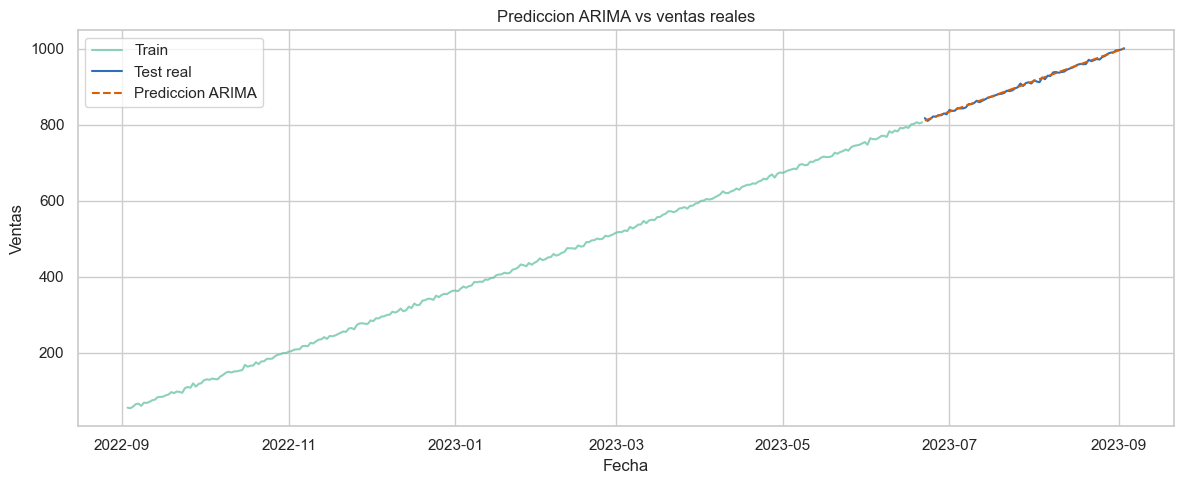

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train", alpha=0.75)
plt.plot(test.index, test.values, label="Test real", color="#2E6FBB")
plt.plot(forecast.index, forecast.values, label="Prediccion ARIMA", color="#D95F02", linestyle="--")
plt.title("Prediccion ARIMA vs ventas reales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

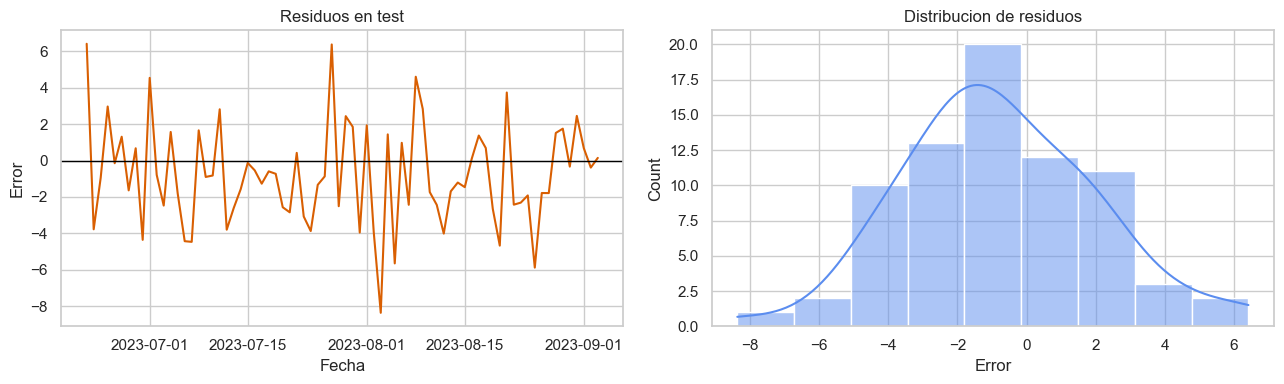

In [14]:
residuals = test - forecast

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(residuals.index, residuals.values, color="#D95F02")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuos en test")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Error")

sns.histplot(residuals, kde=True, ax=axes[1], color="#5B8DEF")
axes[1].set_title("Distribucion de residuos")
axes[1].set_xlabel("Error")

plt.tight_layout()
plt.show()

El modelo predice el conjunto de test con un error bajo. El MAPE aproximado es de 0.26%, lo que indica que el pronostico sigue muy de cerca la evolucion real de ventas.

## Pronostico para los proximos 60 dias

In [15]:
final_model = ARIMA(
    series,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()

future_forecast = final_model.forecast(steps=60)
future_df = pd.DataFrame({
    "date": future_forecast.index,
    "forecast_sales": future_forecast.values,
})
future_df.to_csv(FUTURE_FORECAST_PATH, index=False)

display(future_df.head().round(3))
display(future_df.tail().round(3))

,date,forecast_sales
0,2023-09-04,1002.208
1,2023-09-05,1004.831
2,2023-09-06,1007.430
3,2023-09-07,1010.003
4,2023-09-08,1012.604


,date,forecast_sales
55,2023-10-29,1145.216
56,2023-10-30,1147.816
57,2023-10-31,1150.416
58,2023-11-01,1153.017
59,2023-11-02,1155.617


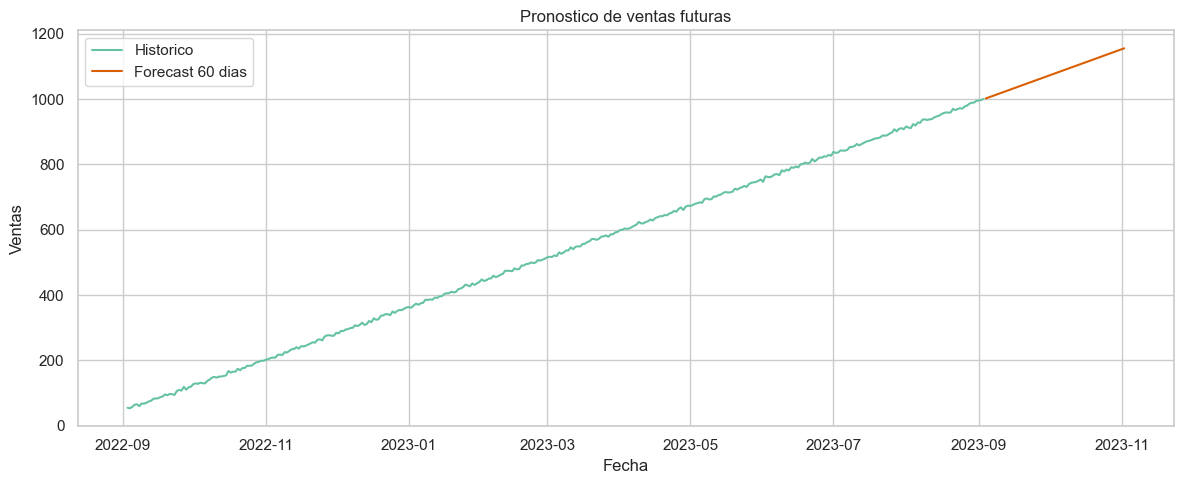

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, label="Historico")
plt.plot(future_forecast.index, future_forecast.values, label="Forecast 60 dias", color="#D95F02")
plt.title("Pronostico de ventas futuras")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()

## Paso 5: Guardado del modelo

In [17]:
with MODEL_PATH.open("wb") as model_file:
    pickle.dump(final_model, model_file)

print(f"Modelo ARIMA guardado en: {MODEL_PATH}")

Modelo ARIMA guardado en: /Users/dragcessa/Desktop/Dragcessa1998-proyecto-de-series-de-tiempo-alternativo-main/models/sales_arima_model.pkl


## Conclusiones

- El tensor de la serie temporal es **diario**.
- La serie presenta una tendencia claramente creciente.
- La serie original no es estacionaria segun la prueba ADF.
- La primera diferenciacion vuelve la serie estacionaria.
- Hay variabilidad y ruido, pero no impiden modelar la tendencia principal.
- El mejor modelo encontrado fue ARIMA `(0, 2, 5)`.
- El modelo obtuvo un MAPE aproximado de 0.26% en test.
- Se guardaron predicciones, metricas y el modelo final en la estructura del proyecto.